In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/retail_sales_dataset.csv')

In [ ]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


## 1. Dataset Overview

The dataset contains 1,000 rows and 9 columns.

There are no missing/null values in the dataset, and the data types of the columns are appropriate for analysis. The dataset contains both numerical and categorical variables that can be used for further exploratory analysis.

In [ ]:
df.shape

(1000, 9)

## 2. Descriptive Statistics

Descriptive statistics are used to understand the central tendency and variability of the numerical variables. Mean, median, mode, and standard deviation are calculated to understand the distribution of the data.

In [ ]:
df.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### Observation

The numerical variables show reasonable distributions with no immediately unusual values based on the descriptive statistics. The mean and median values can be compared to identify potential skewness in the variables.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


## 3. Time Series Analysis

Time series analysis is performed to understand how sales change over time. The sales data will be aggregated at monthly and quarterly levels to identify trends and possible seasonal patterns.

In [ ]:
df['Date']=pd.to_datetime(df['Date'])


In [ ]:
df['Date'].dtype
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


###3.1
 Monthly Sales Trend

Monthly sales are calculated by grouping the transactions by month and summing the total sales amount. This helps identify overall sales trends and possible seasonal patterns.

In [ ]:
monthwise_sales=df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthwise_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


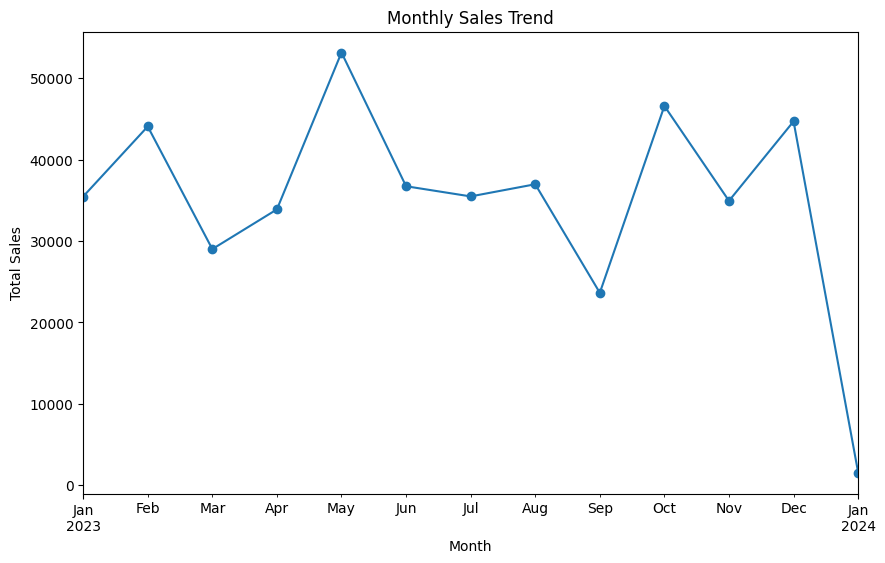

In [ ]:
plt.figure(figsize=(10,6))

monthwise_sales.plot(kind='line',xlabel='Month',ylabel='Total Sales',title='Monthly Sales Trend',marker='o')

plt.show()


##3.2
Quarterly Sales Trend

Quarterly sales are calculated by grouping the transactions by quarter and summing the total sales amount. This helps identify overall sales trends and possible seasonal patterns.

In [ ]:
quarterly_sales=df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
quarterly_sales

,Total Amount
Date,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


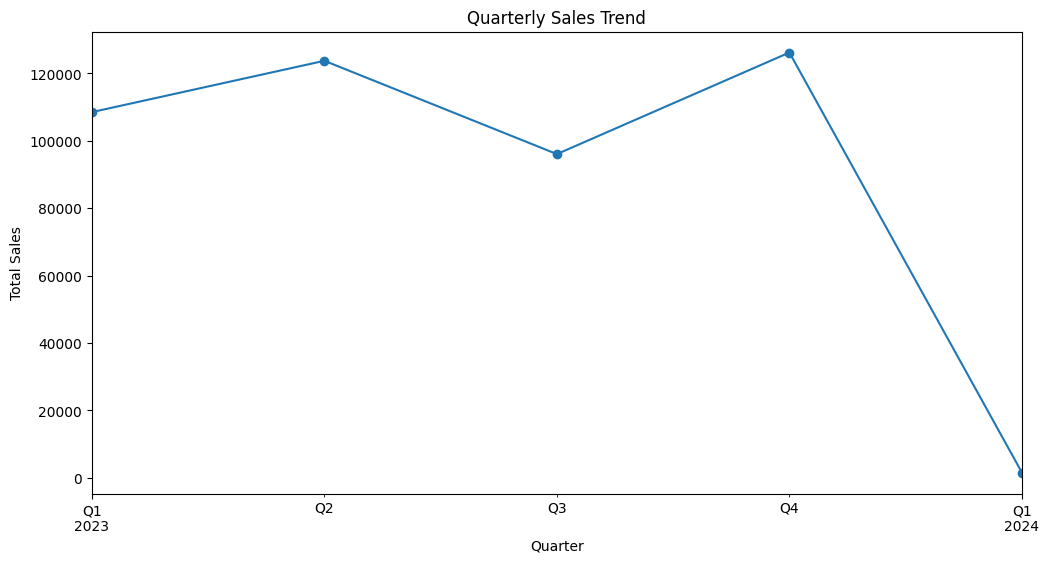

In [ ]:

plt.figure(figsize=(12,6))
quarterly_sales.plot(kind='line',xlabel='Quarter',ylabel='Total Sales',title='Quarterly Sales Trend',marker='o')
plt.show()




Observation-Quartely sales Trend
-sales trend shows strong growth in Q2 and Q4 of 2023 and moderate in Q1 and Q3 and sharp dip in Q1 in 2024.

## 4. Customer Demographics Analysis

Customer demographics are analyzed to understand the age and gender distribution of customers. Age groups are created to identify which customer segments contribute most to the transactions.

In [ ]:
df


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [ ]:
bins=[0,20,40,60,100]
xlabels=['0-20','20-40','40-60','60+']

df['Age Group']=pd.cut(df['Age'],bins=bins,labels=xlabels,
          include_lowest=True )


In [ ]:
age_percentage = df['Age Group'].value_counts(normalize=True).sort_index() * 100

In [ ]:
age_percentage

,proportion
Age Group,
0-20,6.3
20-40,40.3
40-60,44.1
60+,9.3


<Axes: xlabel='Age Group'>

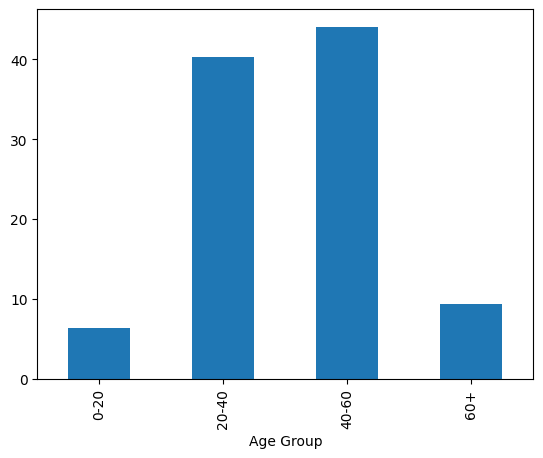

In [ ]:
age_percentage.plot(kind='bar')

### Observation – Age Distribution

- The majority of passengers belong to the **40–60 age group**, accounting for approximately **44%** of the passengers.
- The **20-40 age group** represents around **40.3%** of the passengers.
- The **60+ age group** represents the smallest proportion, at around *9.3%**.
- Passengers aged **0-20** account for approximately **6.3%**.
- Overall, the dataset is concentrated mainly in the **40–60 age range**.

## 4.2 Gender Breakdown

Gender breakdown is used to understand the distribution of customers across different gender categories. This analysis helps identify the composition of the customer base and determine whether the customer distribution is balanced or concentrated toward a particular gender.

In [ ]:
gender_count=df['Gender'].value_counts()

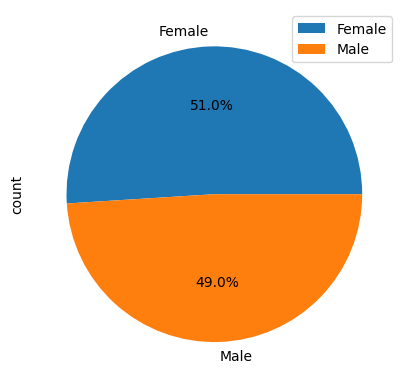

In [ ]:
gender_count.plot(kind='pie',autopct='%1.1f%%')
plt.legend()
plt.show()

### Observation

The gender distribution shows that Female-51% represents the largest proportion of customers, while male-49% represents a smaller proportion. Overall, the customer base appears to be [overall balanced].

In [ ]:
df


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,20-40
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,20-40
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,40-60
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,20-40
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,20-40
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,60+
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,40-60
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,20-40
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,20-40


In [ ]:
bins=[0,20,40,60,80,100]
labels=['0-20','20-40','40-60','60+']

In [ ]:

gender_count=df.groupby('Age Group')['Gender'].value_counts()

/tmp/ipykernel_1384/1990394871.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_count=df.groupby('Age Group')['Gender'].value_counts()


<Axes: xlabel='Age Group'>

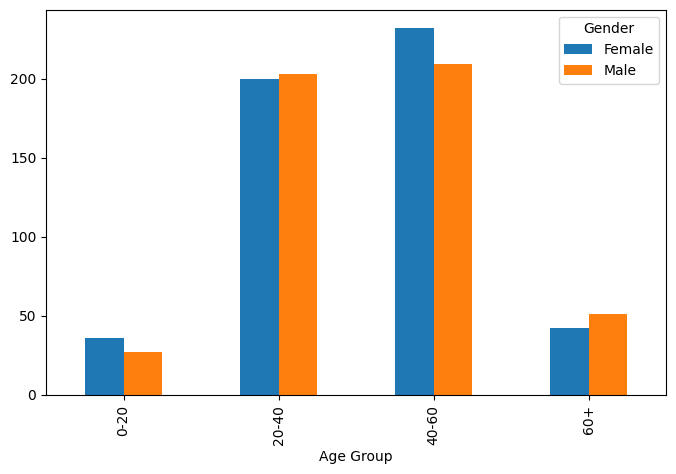

In [ ]:
gender_count.unstack().plot(kind='bar', figsize=(8,5))

###5.1 Definition – Product Category Analysis

This analysis examines the sales performance of different product categories based on the total quantity sold. It helps identify which categories have the highest customer demand.

In [ ]:
df


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,20-40
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,20-40
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,40-60
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,20-40
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,20-40
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,60+
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,40-60
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,20-40
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,20-40


In [ ]:

category_sales=df['Product Category'].value_counts().sort_values(ascending=False)
category_sales

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


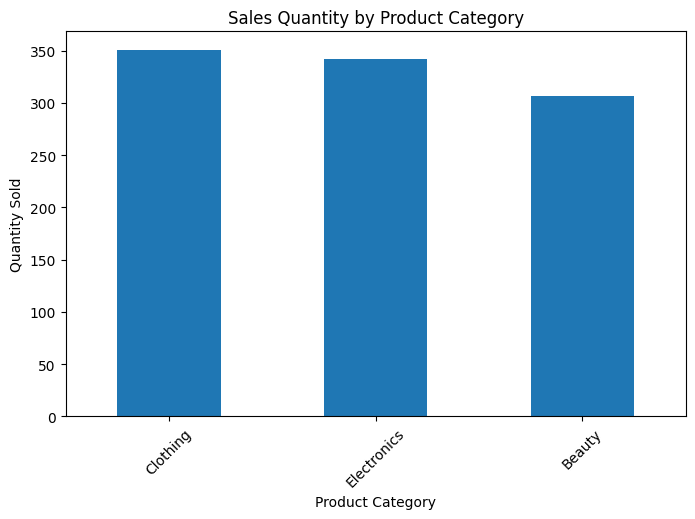

In [ ]:
category_sales.plot(kind='bar', figsize=(8,5))

plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.title('Sales Quantity by Product Category')
plt.xticks(rotation=45)
plt.show()

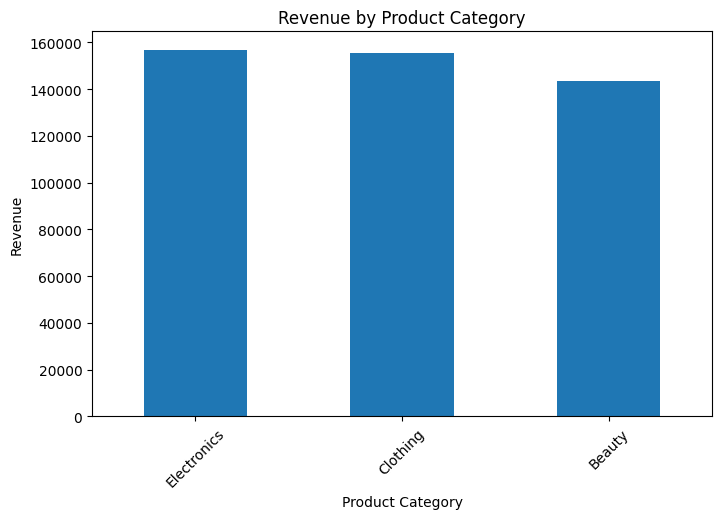

In [ ]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar', figsize=(8,5))

plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.title('Revenue by Product Category')
plt.xticks(rotation=45)
plt.show()

### Observation – Product Category Sales

- The clothingy has the highest number of units sold.
- The Beauty has the lowest sales quantity.
- Overall, the results show that customer demand varies across different product categories.

### Definition – Correlation Heatmap

A correlation heatmap is used to visualize the relationships between numerical variables in the dataset. The correlation coefficient ranges from -1 to +1, where values closer to +1 indicate a positive relationship, values closer to -1 indicate a negative relationship, and values near 0 indicate little or no linear relationship.

In [ ]:
df.corr(numeric_only=True)


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


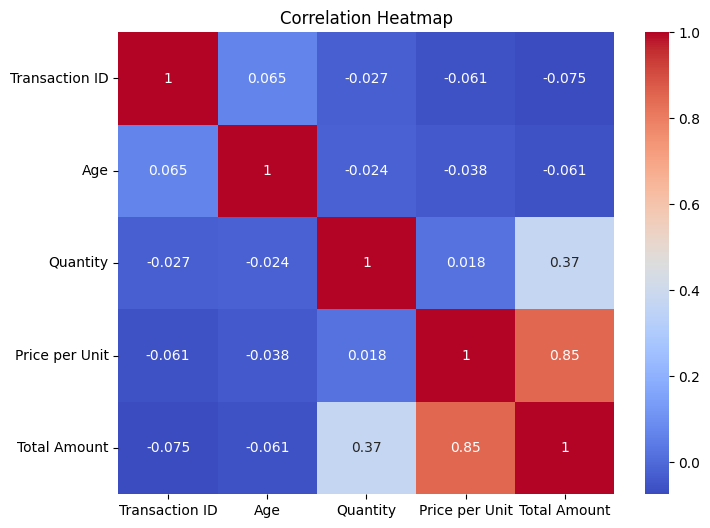

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

### Observation – Correlation Heatmap

- **Price per Unit and Total Amount** have a strong positive correlation of approximately **0.85**, indicating that higher-priced items generally contribute to higher transaction amounts.
- **Quantity and Total Amount** have a moderate positive correlation of approximately **0.37**, suggesting that purchasing more items generally increases the total transaction amount.
- **Quantity and Price per Unit** have almost no correlation, with a value of approximately **0.02**.
- **Age and Total Amount** have a very weak negative correlation of approximately **-0.06**, indicating little to no linear relationship between age and transaction amount.

Price vs Total Amount

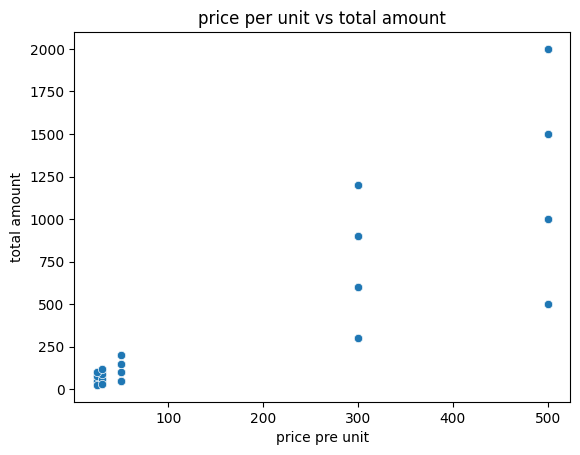

In [ ]:
sns.scatterplot(data=df, x='Price per Unit', y='Total Amount')

plt.title('price per unit vs total amount')
plt.xlabel('price pre unit')
plt.ylabel('total amount')
plt.show()

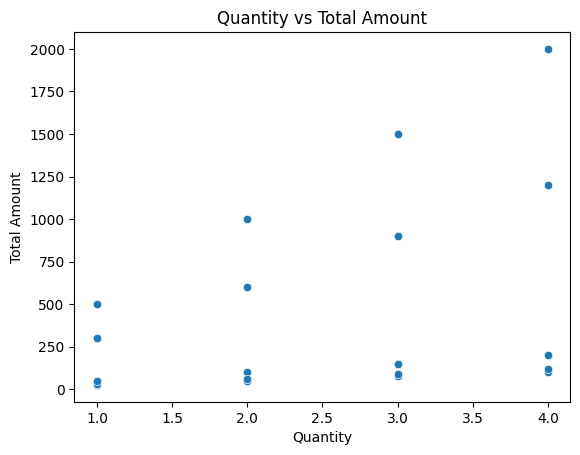

In [ ]:
sns.scatterplot(data=df, x='Quantity', y='Total Amount')

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.show()

## Conclusion

The analysis provides useful insights into sales performance, customer demographics, and product category performance. The findings show differences in customer purchasing behavior and revenue contribution across categories. The analysis can help the business improve inventory planning, marketing strategies, and sales performance.

### Business Recommendations

1. **Focus on high-performing product categories**
   - Allocate more inventory and marketing resources to the categories generating the highest sales quantity and revenue.
   - This can help maintain product availability and maximize revenue from popular categories.

2. **Optimize inventory based on sales demand**
   - Maintain higher stock levels for frequently purchased categories and reduce excess inventory for low-performing categories.
   - This can reduce the risk of stockouts as well as unnecessary inventory costs.

3. **Use pricing and quantity insights to improve revenue**
   - Since price per unit has a strong positive relationship with total transaction value, the business can evaluate suitable pricing and product-bundling strategies to increase transaction value.